# Data Mining Project 9: E-commerce Product Recommendation

This project analyzes customer browsing and purchasing behavior from an e-commerce electronics store and builds a product recommendation system.

### Tasks
1. Collect customer browsing data.
2. Preprocess the behavioral dataset.
3. Analyze customer preferences.
4. Build a recommendation model.
5. Generate product recommendation results.

**Dataset:** eCommerce Events History in Electronics Store  
**Source:** Kaggle  
**Approach:** Item-based collaborative filtering using cosine similarity.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

## 2. Import Dataset from Kaggle

In [2]:
path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-electronics-store")

print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 20.3M/20.3M [00:00<00:00, 95.3MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-electronics-store/versions/1
Files: ['events.csv']


In [3]:
# Find the CSV file automatically
csv_files = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
print("CSV files found:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))
df.head()

CSV files found: ['events.csv']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


## 3. Basic Dataset Information

In [4]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (885129, 9)

Columns:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_time,885129,845041,2021-02-04 21:48:32 UTC,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,885129,3,view,793748,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,885129.0,NaN,NaN,NaN,1906620.535893,1458708.09933,102.0,698803.0,1452883.0,3721194.0,4183880.0
category_id,885129.0,NaN,NaN,NaN,2144422967987037184.0,616510516083801.25,2144415921001725952.0,2144415922528452608.0,2144415925011480832.0,2144415927519674624.0,2227847332769039360.0
category_code,648910,107,computers.components.videocards,116717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,672765,999,asus,27706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,885129.0,NaN,NaN,NaN,146.328713,296.807683,0.22,26.46,65.71,190.49,64771.06
user_id,885129.0,NaN,NaN,NaN,1515915625558965504.0,37472865.571268,1515915625353227008.0,1515915625533004288.0,1515915625554085376.0,1515915625594517504.0,1515915625611024128.0
user_session,884964,490398,nFlhu5QzOd,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Preprocessing

In [7]:
# Convert event_time to datetime
df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows without the essential recommendation fields
df = df.dropna(subset=["user_id", "product_id", "event_type"])

print("Shape after preprocessing:", df.shape)
print("\nMissing values:")
print(df[["user_id", "product_id", "event_type"]].isnull().sum())

Shape after preprocessing: (884474, 9)

Missing values:
user_id       0
product_id    0
event_type    0
dtype: int64


## 5. Analyze Customer Behavior

event_type
view        793099
cart         54032
purchase     37343
Name: count, dtype: int64


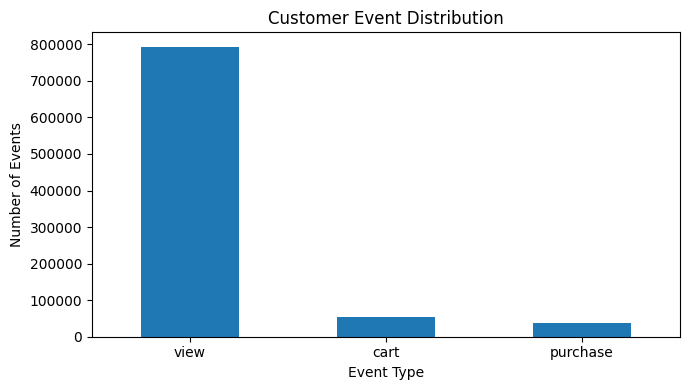

In [8]:
event_counts = df["event_type"].value_counts()

print(event_counts)

plt.figure(figsize=(7, 4))
event_counts.plot(kind="bar")
plt.title("Customer Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Most popular products based on customer interactions
top_products = (
    df["product_id"]
    .value_counts()
    .head(10)
)

print("Top 10 Most Interacted Products:")
print(top_products)

Top 10 Most Interacted Products:
product_id
1821813    14552
4099645     7086
3791351     6901
3829355     5759
1785245     5118
809948      4287
1830099     4198
893196      3911
4154414     3707
3791509     3613
Name: count, dtype: int64


Top 10 Brands:
brand
asus         27660
gigabyte     27652
msi          24864
palit        24787
samsung      23188
amd          20095
canon        18430
panasonic    11977
pioneer      11463
sirius       11406
Name: count, dtype: int64


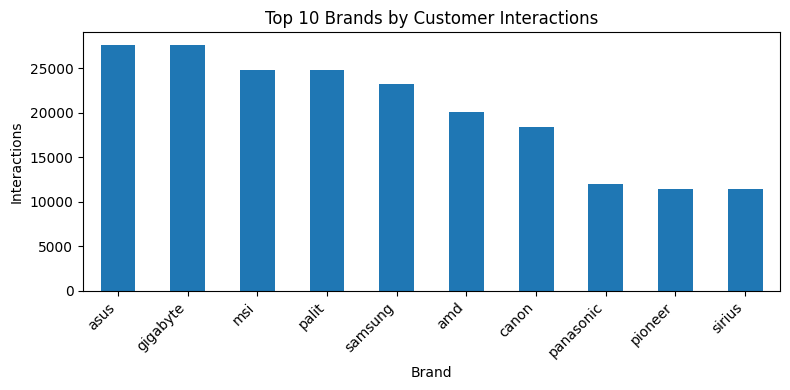

In [10]:
# Most popular brands
if "brand" in df.columns:
    top_brands = df["brand"].dropna().value_counts().head(10)
    print("Top 10 Brands:")
    print(top_brands)

    plt.figure(figsize=(8, 4))
    top_brands.plot(kind="bar")
    plt.title("Top 10 Brands by Customer Interactions")
    plt.xlabel("Brand")
    plt.ylabel("Interactions")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 6. Create Customer-Product Interaction Scores

Different customer actions represent different levels of interest.

- **View = 1**
- **Add to cart = 3**
- **Purchase = 5**
- **Remove from cart = 0.5**

These weights convert browsing behavior into a single interaction score.

In [11]:
event_weights = {
    "view": 1,
    "cart": 3,
    "purchase": 5,
    "remove_from_cart": 0.5
}

df["interaction_score"] = df["event_type"].map(event_weights).fillna(0)

interaction_df = (
    df.groupby(["user_id", "product_id"])["interaction_score"]
    .sum()
    .reset_index()
)

interaction_df.head()

,user_id,product_id,interaction_score
0,1515915625353226922,4101974,1.0
1,1515915625353230067,3506650,1.0
2,1515915625353230683,124883,1.0
3,1515915625353230683,125325,1.0
4,1515915625353230683,254763,4.0


## 7. Prepare Data for Recommendation Model

In [12]:
# Keep the most frequently interacted products to make the
# recommendation matrix efficient while retaining popular products.
top_product_ids = (
    interaction_df.groupby("product_id")["interaction_score"]
    .sum()
    .sort_values(ascending=False)
    .head(3000)
    .index
)

model_df = interaction_df[
    interaction_df["product_id"].isin(top_product_ids)
].copy()

# Keep users with at least two product interactions
user_counts = model_df.groupby("user_id")["product_id"].nunique()
active_users = user_counts[user_counts >= 2].index

model_df = model_df[model_df["user_id"].isin(active_users)].copy()

print("Modeling rows:", len(model_df))
print("Unique users:", model_df["user_id"].nunique())
print("Unique products:", model_df["product_id"].nunique())

Modeling rows: 106553
Unique users: 34955
Unique products: 2870


In [13]:
user_index = {
    user_id: index
    for index, user_id in enumerate(model_df["user_id"].unique())
}

product_index = {
    product_id: index
    for index, product_id in enumerate(model_df["product_id"].unique())
}

rows = model_df["user_id"].map(user_index)
cols = model_df["product_id"].map(product_index)
values = model_df["interaction_score"]

user_product_matrix = csr_matrix(
    (values, (rows, cols)),
    shape=(len(user_index), len(product_index))
)

print("Interaction matrix shape:", user_product_matrix.shape)
print("Non-zero interactions:", user_product_matrix.nnz)

Interaction matrix shape: (34955, 2870)
Non-zero interactions: 106553


## 8. Build Item-Based Recommendation Model

The recommendation model uses **cosine similarity** between products.

Products interacted with by similar customers receive higher similarity scores.  
For a selected customer, products similar to their previously interacted products are recommended.

In [14]:
# Transpose so each row represents a product
product_user_matrix = user_product_matrix.T.tocsr()

model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",
    n_neighbors=11
)

model.fit(product_user_matrix)

print("Recommendation model trained successfully.")

Recommendation model trained successfully.


## 9. Generate Product Recommendations

In [15]:
reverse_product_index = {
    index: product_id
    for product_id, index in product_index.items()
}

def recommend_products(user_id, n_recommendations=5):
    if user_id not in user_index:
        return pd.DataFrame(columns=["product_id", "score"])

    user_row = user_product_matrix[user_index[user_id]]
    interacted_indices = user_row.indices

    if len(interacted_indices) == 0:
        return pd.DataFrame(columns=["product_id", "score"])

    scores = {}

    for product_idx in interacted_indices:
        distances, neighbors = model.kneighbors(
            product_user_matrix[product_idx],
            n_neighbors=11
        )

        for distance, neighbor_idx in zip(distances[0], neighbors[0]):
            neighbor_idx = int(neighbor_idx)

            if neighbor_idx == product_idx:
                continue

            similarity = 1 - float(distance)
            product_id = reverse_product_index[neighbor_idx]

            if neighbor_idx not in interacted_indices:
                scores[product_id] = scores.get(product_id, 0) + similarity

    recommendations = (
        pd.DataFrame(
            list(scores.items()),
            columns=["product_id", "score"]
        )
        .sort_values("score", ascending=False)
        .head(n_recommendations)
        .reset_index(drop=True)
    )

    return recommendations

## 10. Test the Recommendation System

In [16]:
# Select a customer who has enough interaction history
sample_user = model_df["user_id"].value_counts().index[0]

print("Selected customer:", sample_user)

print("\nPreviously interacted products:")
print(
    model_df[model_df["user_id"] == sample_user]
    .sort_values("interaction_score", ascending=False)
    [["product_id", "interaction_score"]]
    .head(10)
)

Selected customer: 1515915625599852988

Previously interacted products:
        product_id  interaction_score
471115     1413340               10.0
471113     1413338                8.0
471126     1570050                7.0
471114     1413339                7.0
471174     3791077                6.0
471142     1735481                6.0
471128     1571192                5.0
471116     1413341                5.0
471089      877060                5.0
471176     3791351                4.0


In [17]:
recommendations = recommend_products(sample_user, 5)

print("Top 5 Recommended Products:")
recommendations

Top 5 Recommended Products:


,product_id,score
0,4171147,2.672363
1,880499,2.336264
2,5913,2.282872
3,1484739,2.201846
4,3647921,1.831798


## 11. Add Product Details to Recommendations

In [18]:
# Add available product information such as category, brand and price.
product_details = (
    df[["product_id", "category_code", "brand", "price"]]
    .drop_duplicates("product_id")
)

final_recommendations = recommendations.merge(
    product_details,
    on="product_id",
    how="left"
)

final_recommendations

,product_id,score,category_code,brand,price
0,4171147,2.672363,computers.components.hdd,smartbuy,73.24
1,880499,2.336264,computers.components.power_supply,cougar,47.32
2,5913,2.282872,computers.components.hdd,NaN,49.57
3,1484739,2.201846,NaN,zalman,54.52
4,3647921,1.831798,computers.components.videocards,msi,268.51


## 12. Simple Recommendation Evaluation

For a simple evaluation, customers with at least three interacted products are selected. One product is treated as a hidden test item, while the remaining products are used as the customer's history.

**Precision@5** measures how many of the top five recommendations match the hidden product.

In [19]:
def precision_at_5(user_id):
    user_data = (
        model_df[model_df["user_id"] == user_id]
        .sort_values("interaction_score", ascending=False)
    )

    if len(user_data) < 3:
        return None

    hidden_product = user_data.iloc[-1]["product_id"]
    history_products = set(user_data.iloc[:-1]["product_id"])

    # Temporarily use the customer's history directly
    # to calculate candidate recommendations.
    scores = {}

    for product_id in history_products:
        product_idx = product_index[product_id]

        distances, neighbors = model.kneighbors(
            product_user_matrix[product_idx],
            n_neighbors=11
        )

        for distance, neighbor_idx in zip(distances[0], neighbors[0]):
            neighbor_idx = int(neighbor_idx)

            if reverse_product_index[neighbor_idx] in history_products:
                continue

            similarity = 1 - float(distance)
            candidate = reverse_product_index[neighbor_idx]
            scores[candidate] = scores.get(candidate, 0) + similarity

    top5 = sorted(scores, key=scores.get, reverse=True)[:5]

    return int(hidden_product in top5)

In [20]:
eligible_users = (
    model_df.groupby("user_id")["product_id"]
    .nunique()
)

eligible_users = eligible_users[eligible_users >= 3].index[:100]

results = [
    precision_at_5(user_id)
    for user_id in eligible_users
]

results = [value for value in results if value is not None]

precision_5 = np.mean(results) if results else 0

print("Evaluated users:", len(results))
print("Precision@5:", round(precision_5, 4))

Evaluated users: 100
Precision@5: 0.34


## Conclusion

The e-commerce behavioral dataset was preprocessed and analyzed to understand customer preferences. Customer actions were converted into weighted interaction scores, and an item-based collaborative filtering model using cosine similarity was built. The model generates personalized product recommendations based on products that a customer previously interacted with.

This approach directly addresses the project requirements of analyzing browsing behavior, building a recommendation model, and generating personalized product recommendations.